In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [47]:
data = pd.read_csv(r'D:\4th semester\Data analysis\project\Fraud.csv')

In [48]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [49]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [50]:
data.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [51]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [52]:
data.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1

In [53]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [54]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

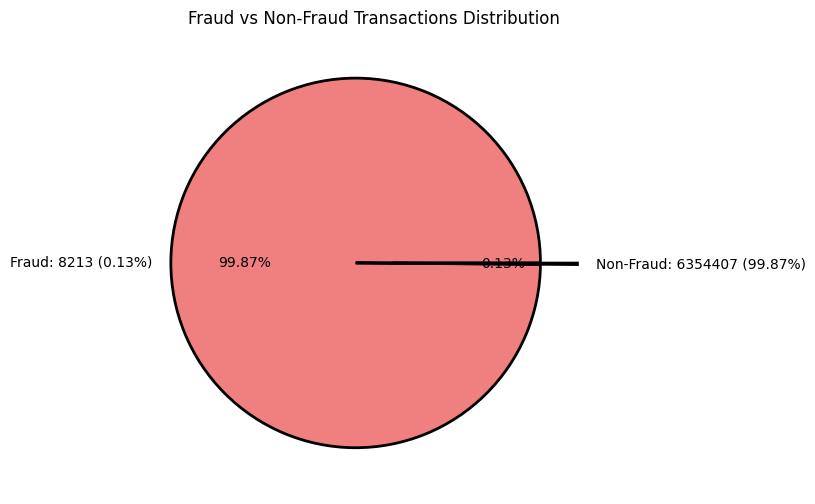

In [55]:
plt.figure(figsize=(10,6))
sizes = data['isFraud'].value_counts()
labels = [f'Fraud: {sizes[1]} ({sizes[1] / sum(sizes) * 100:.2f}%)', 
          f'Non-Fraud: {sizes[0]} ({sizes[0] / sum(sizes) * 100:.2f}%)']
explode = [0.1, 0.1]
color = ['lightcoral', 'red']  
plt.pie(sizes, explode=explode, labels=labels, autopct="%1.2f%%", colors=color,wedgeprops={'edgecolor': 'black', 'linewidth': 2})
plt.title("Fraud vs Non-Fraud Transactions Distribution")
plt.show()

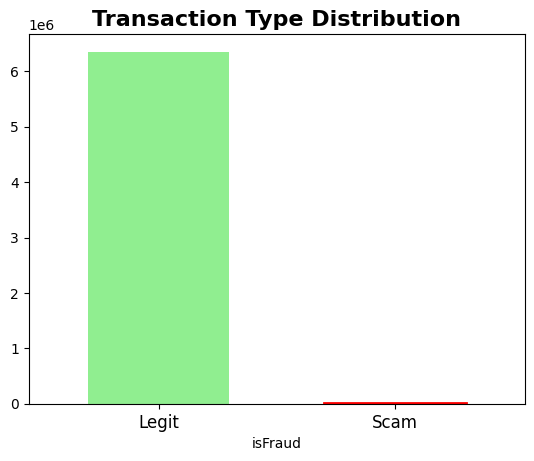

In [ ]:
#occurrence of each class (fraud and non-fraud)
count_classes = data['isFraud'].value_counts()
ax = count_classes.plot(kind='bar', rot=0, color=['lightgreen', 'salmon'], width=0.6)
plt.title('Transaction Type Distribution', fontsize=16, fontweight='bold')
plt.xticks(range(2), ['Legit', 'Scam'], fontsize=12)

#highlighting fraud (Scam),thicker border for fraud bar
for i in range(2):
    if i == 1:
        ax.patches[i].set_edgecolor('red') 
        ax.patches[i].set_linewidth(2)  
plt.show()

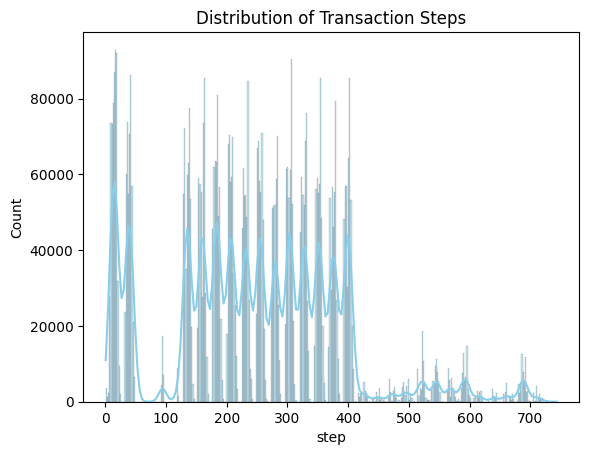

In [57]:
sns.histplot(data['step'], kde=True, color='skyblue')
plt.title("Distribution of Transaction Steps")
plt.show()

In [58]:
data.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

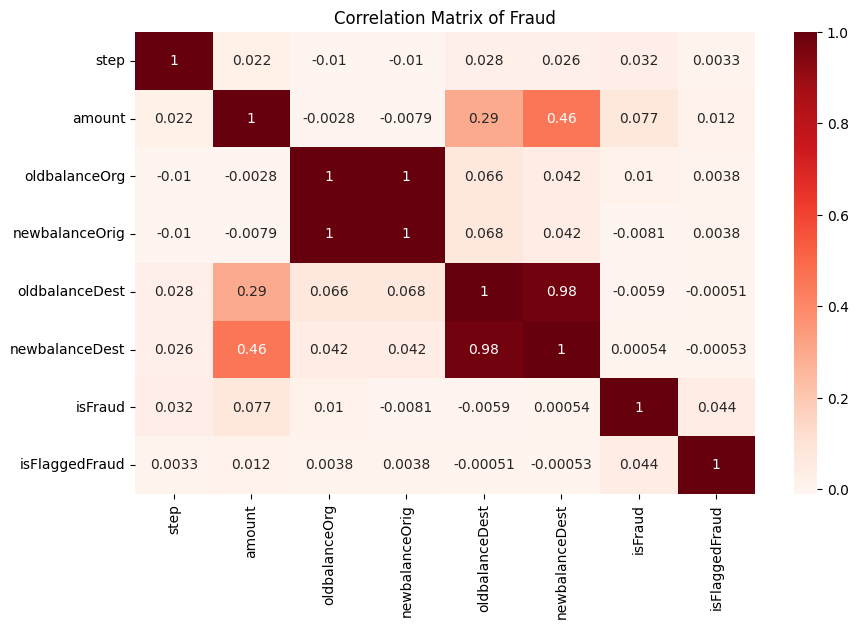

In [59]:
#numeric columns
numeric_data = data.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Reds')
plt.title("Correlation Matrix of Fraud")
plt.show()


In [60]:
# Define feature columns (X) and target column (y)
X = data.iloc[:, 0:-1]  # All columns except the last one
y = data.iloc[:, -1]    # The last column (target variable)

In [61]:
X.shape

(6362620, 10)

In [62]:
y.shape

(6362620,)

In [ ]:
#split data into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [64]:
X_train.shape

(4771965, 10)

In [65]:
X_test.shape

(1590655, 10)

In [66]:
y_train.shape

(4771965,)

In [67]:
y_test.shape

(1590655,)

In [74]:
logit = LogisticRegression(max_iter=1000)  # max_iter ensures convergence if needed

In [86]:
X_train = pd.get_dummies(X_train, columns=['type'], drop_first=True)

In [87]:
X_train = X_train.drop(columns=['nameOrig', 'nameDest'])

In [ ]:
#fit model on the training data
logit.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#predict on training and test data
y_pred_train = logit.predict(X_train)
y_pred_test = logit.predict(X_test)

In [94]:
#confusion Matrix
print("Confusion Matrix (Train):")
print(confusion_matrix(y_train, y_pred_train))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

Confusion Matrix (Train):
[[4771955       0]
 [      6       4]]
Confusion Matrix (Test):
[[1590649       0]
 [      2       4]]


In [95]:
#classification Report
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred_train))
print("Classification Report (Test):")
print(classification_report(y_test, y_pred_test))


Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   4771955
           1       1.00      0.40      0.57        10

    accuracy                           1.00   4771965
   macro avg       1.00      0.70      0.79   4771965
weighted avg       1.00      1.00      1.00   4771965

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1590649
           1       1.00      0.67      0.80         6

    accuracy                           1.00   1590655
   macro avg       1.00      0.83      0.90   1590655
weighted avg       1.00      1.00      1.00   1590655



In [96]:
#accuracy Score
print("\nAccuracy (Train):", accuracy_score(y_train, y_pred_train))
print("Accuracy (Test):", accuracy_score(y_test, y_pred_test))


Accuracy (Train): 0.9999987426563272
Accuracy (Test): 0.9999987426563272


In [97]:
print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")

Training Accuracy: 1.00
Testing Accuracy: 1.00
